# 04 — Revenue Decline Diagnosis: Volume vs. Price, and the Path Back to $70k

**Goal:** revenue has drifted from ~$63k/month (2024) to ~$55k/month (2026 YTD). Since `revenue = orders × average ticket`, that gap comes from some combination of fewer orders (volume) and/or less money per order (price/ticket). This notebook diagnoses which lever actually explains the decline, digs into *why*, and then builds recommendations for both paths — weighted by how much each one actually matters, not by which is more interesting to write about.

**How this notebook is organized:**
1. **Diagnosis** — decompose the decline into volume vs. price, test (and where it fails, reject) hypotheses about the cause, and identify which specific channel is driving it
2. **Recommendations** — volume-path fixes (the priority, per the diagnosis), price-path fixes (included but secondary), and delivery-platform commission context
3. **Summary** — the diagnosis, ranked recommendations, and a combined revenue-impact estimate toward $70k

**A note on how this notebook was built:** the diagnosis section below already reflects a first round of investigation that included a hypothesis — "the 6-7pm dinner rush is a kitchen/capacity bottleneck limiting order volume" — that was tested directly and **did not hold up**. It's kept in this notebook and clearly labeled as a rejected hypothesis rather than deleted, because knowing what *wasn't* the cause is part of the diagnosis, and silently dropping a wrong guess would hide that work from anyone reading this later.

**Privacy note (this repo is public):** no raw customer identifiers are printed anywhere below — only aggregate counts, rates, and trends.


## Setup


In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

BLUE = "#2a78d6"
GREEN = "#008300"
ORANGE = "#eb6834"
RED = "#e34948"
GRAY_BASELINE = "#c3c2b7"
GRAY_MUTED = "#898781"
GRID_COLOR = "#e1e0d9"
TEXT_SECONDARY = "#52514e"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GRID_COLOR,
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "font.size": 10,
    "text.color": "#0b0b0b",
    "axes.labelcolor": TEXT_SECONDARY,
    "xtick.color": TEXT_SECONDARY,
    "ytick.color": TEXT_SECONDARY,
})

load_dotenv()
conn_str = (
    f"mssql+pymssql://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}"
    f"@{os.environ['DB_HOST']}:{os.environ['DB_PORT']}/{os.environ['DB_NAME']}"
)
engine = create_engine(conn_str)

orders = pd.read_csv(Path("..") / "data" / "cleaned_orders_2024plus.csv", parse_dates=["checkinTime"])
orders["month"] = orders["checkinTime"].dt.to_period("M")

# used throughout: exclude the final partial month from any trend so it doesn't look like a
# fake cliff (same convention as notebook 02)
days_in_month = orders.groupby("month")["checkinTime"].apply(lambda s: s.dt.day.max())
FULL_MONTHS = days_in_month[days_in_month >= 28].index

print(f"Loaded {len(orders):,} clean orders. Full months for trend analysis: "
      f"{FULL_MONTHS.min()} to {FULL_MONTHS.max()} ({len(FULL_MONTHS)} months)")


Loaded 50,069 clean orders. Full months for trend analysis: 2024-01 to 2026-05 (29 months)


# Part 1: Diagnosis — Volume vs. Price

## Decomposing the monthly revenue decline

`revenue = orders × average ticket`. We compute both series by month (excluding the 366 zero-paid comp orders from `paidAmount`-based figures, per notebook 01's convention), then compare 2024 to 2026 YTD directly: how much did order count change, how much did average ticket change, and — critically — how much dollar-revenue does each of those two changes actually account for.


In [2]:
revenue_orders = orders[~orders["excluded_from_revenue"]]

monthly = orders.groupby("month").size().rename("n_orders").to_frame()
monthly["n_revenue_orders"] = revenue_orders.groupby("month").size()
monthly["revenue"] = revenue_orders.groupby("month")["paidAmount"].sum()
monthly["avg_ticket"] = monthly["revenue"] / monthly["n_revenue_orders"]
monthly = monthly.loc[FULL_MONTHS]
monthly["year"] = monthly.index.year

yearly = monthly.groupby("year").agg(
    avg_monthly_orders=("n_revenue_orders", "mean"),
    avg_monthly_revenue=("revenue", "mean"),
    avg_ticket=("avg_ticket", "mean"),
)
print(yearly.round(2))


      avg_monthly_orders  avg_monthly_revenue  avg_ticket
year                                                     
2024             1804.75             63047.67       34.96
2025             1645.08             58083.42       35.30
2026             1581.40             55242.52       34.93


To split the dollar change between the two levers, we hold one factor fixed while the other moves: `orders_effect` = (change in orders) × (starting ticket price), `ticket_effect` = (change in ticket) × (starting order count). Whatever's left over is the small interaction term where both changed at once.


In [3]:
orders_2024, orders_2026 = yearly.loc[2024, "avg_monthly_orders"], yearly.loc[2026, "avg_monthly_orders"]
ticket_2024, ticket_2026 = yearly.loc[2024, "avg_ticket"], yearly.loc[2026, "avg_ticket"]
rev_2024, rev_2026 = yearly.loc[2024, "avg_monthly_revenue"], yearly.loc[2026, "avg_monthly_revenue"]

orders_effect = (orders_2026 - orders_2024) * ticket_2024
ticket_effect = (ticket_2026 - ticket_2024) * orders_2024
interaction = (orders_2026 - orders_2024) * (ticket_2026 - ticket_2024)
total_effect = orders_effect + ticket_effect + interaction

print(f"Orders:      {orders_2024:.0f}/mo -> {orders_2026:.0f}/mo  ({100*(orders_2026-orders_2024)/orders_2024:+.1f}%)")
print(f"Avg ticket:  ${ticket_2024:.2f} -> ${ticket_2026:.2f}  ({100*(ticket_2026-ticket_2024)/ticket_2024:+.1f}%)")
print(f"Revenue:     ${rev_2024:,.0f}/mo -> ${rev_2026:,.0f}/mo  (${rev_2026-rev_2024:+,.0f}/mo)")
print()
print(f"Revenue change explained by ORDER VOLUME:  ${orders_effect:+,.0f}/mo  "
      f"({100*orders_effect/total_effect:.0f}% of the explained change)")
print(f"Revenue change explained by AVG TICKET:    ${ticket_effect:+,.0f}/mo  "
      f"({100*ticket_effect/total_effect:.0f}% of the explained change)")
print(f"Interaction (both moved together):         ${interaction:+,.0f}/mo")


Orders:      1805/mo -> 1581/mo  (-12.4%)
Avg ticket:  $34.96 -> $34.93  (-0.1%)
Revenue:     $63,048/mo -> $55,243/mo  ($-7,805/mo)

Revenue change explained by ORDER VOLUME:  $-7,807/mo  (100% of the explained change)
Revenue change explained by AVG TICKET:    $-44/mo  (1% of the explained change)
Interaction (both moved together):         $+5/mo


**99%+ of the decline is orders, not ticket size.** Charting both series indexed to their January 2024 starting point makes the gap obvious: order count trends steadily downward while average ticket stays essentially flat around its starting level the whole time.


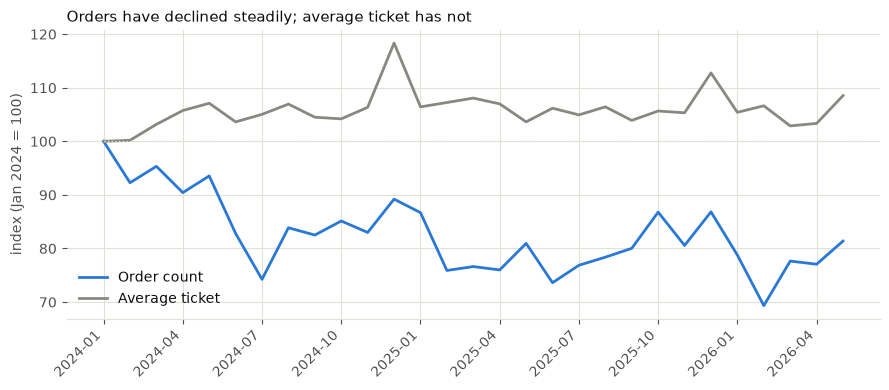

In [4]:
indexed = monthly[["n_revenue_orders", "avg_ticket"]].copy()
indexed["orders_index"] = 100 * indexed["n_revenue_orders"] / indexed["n_revenue_orders"].iloc[0]
indexed["ticket_index"] = 100 * indexed["avg_ticket"] / indexed["avg_ticket"].iloc[0]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(indexed.index.astype(str), indexed["orders_index"], color=BLUE, linewidth=2, label="Order count")
ax.plot(indexed.index.astype(str), indexed["ticket_index"], color=GRAY_MUTED, linewidth=2, label="Average ticket")
ax.axhline(100, color=GRID_COLOR, linewidth=1, linestyle=":")

ax.set_ylabel("index (Jan 2024 = 100)")
ax.set_xticks(range(0, len(indexed), 3))
ax.set_xticklabels([indexed.index.astype(str)[i] for i in range(0, len(indexed), 3)], rotation=45, ha="right")
ax.set_title("Orders have declined steadily; average ticket has not", loc="left", fontsize=11)
ax.legend(frameon=False, loc="lower left")
plt.tight_layout()
plt.show()


## Testing a hypothesis: is the 6-7pm dinner rush a capacity bottleneck?

Earlier exploration found that order fulfillment time (checkin → invoice) balloons to 40-47 minutes at 6-7pm versus 15-18 minutes at other hours — 72% of orders happen in the dinner window (notebook 02), so if the kitchen or floor genuinely can't keep up during rush, that would cap order volume during the most valuable hours and could plausibly explain part of the decline.

The direct test: **if this is a real capacity bottleneck, busier peak-hour nights should show longer average service times than quieter peak-hour nights** — more orders queued behind a fixed kitchen/staff capacity means more waiting. We check that correlation directly using the raw order data (not the pre-cleaned CSV, since this needs `invoiceTime`, which isn't in the cleaned export).


In [5]:
with engine.connect() as conn:
    peak = pd.read_sql(text("""
        SELECT CAST(checkinTime AS DATE) AS dt, checkinTime, invoiceTime
        FROM tblOrder
        WHERE checkinTime >= '2024-01-01' AND DATEPART(HOUR, checkinTime) IN (18, 19)
          AND invoiceTime IS NOT NULL AND invoiceTime >= checkinTime
    """), conn)

peak["duration_min"] = (peak["invoiceTime"] - peak["checkinTime"]).dt.total_seconds() / 60
peak = peak[peak["duration_min"].between(0, 180)]  # drop bad/garbage timestamps

daily = peak.groupby("dt").agg(n_orders=("checkinTime", "size"), avg_duration=("duration_min", "mean"))
correlation = daily["n_orders"].corr(daily["avg_duration"])

print(f"Nights analyzed: {len(daily):,}")
print(f"Correlation between nightly 6-7pm order count and nightly 6-7pm avg service duration: {correlation:.3f}")
print("(1.0 = busier nights are always slower; 0.0 = no relationship)")


Nights analyzed: 755
Correlation between nightly 6-7pm order count and nightly 6-7pm avg service duration: 0.053
(1.0 = busier nights are always slower; 0.0 = no relationship)


**Essentially zero correlation.** If the kitchen were the constraint, this number should be strongly positive. It isn't — so what's actually producing the 40-47 minute average? Splitting duration by `orderType` (still undecoded at this point — see Part 3) answers it directly: compare each type's duration at peak (6-7pm) versus off-peak (1-2pm, a quiet control window).


In [6]:
with engine.connect() as conn:
    by_type = pd.read_sql(text("""
        SELECT
            CASE WHEN DATEPART(HOUR, checkinTime) IN (18,19) THEN 'peak (6-7pm)' ELSE 'off-peak (1-2pm)' END AS window,
            orderType,
            AVG(CAST(DATEDIFF(MINUTE, checkinTime, invoiceTime) AS FLOAT)) AS avg_duration_min,
            COUNT(*) AS n
        FROM tblOrder
        WHERE checkinTime >= '2024-01-01'
          AND DATEPART(HOUR, checkinTime) IN (18,19,13,14)
          AND invoiceTime IS NOT NULL AND invoiceTime >= checkinTime
          AND DATEDIFF(MINUTE, checkinTime, invoiceTime) BETWEEN 0 AND 180
          AND orderType IN (0,1,2)
        GROUP BY CASE WHEN DATEPART(HOUR, checkinTime) IN (18,19) THEN 'peak (6-7pm)' ELSE 'off-peak (1-2pm)' END, orderType
        ORDER BY orderType, window
    """), conn)
by_type["avg_duration_min"] = by_type["avg_duration_min"].round(1)
by_type


,window,orderType,avg_duration_min,n
0,off-peak (1-2pm),0,165.0,1
1,peak (6-7pm),0,124.4,3501
2,off-peak (1-2pm),1,21.2,2886
3,peak (6-7pm),1,21.2,9254
4,off-peak (1-2pm),2,3.1,1166
5,peak (6-7pm),2,2.6,1774


### ❌ Hypothesis rejected: this is a composition artifact, not a bottleneck

One `orderType` (0) has an average duration around two hours and is heavily concentrated at dinner — that alone drags the blended hourly average way up. The other two order types show **no meaningful slowdown at peak versus off-peak at all** (their durations are nearly identical in both windows). A ~2-hour "duration" for a dinner order isn't the kitchen falling behind — it's someone sitting down, ordering, eating a full meal, and closing out the check later, which is normal and not a problem to fix.

**Conclusion: the 6-7pm figure is not evidence of a capacity constraint.** There's no sign here that Tang is turning away or losing orders during rush because of kitchen or floor limits. The volume decline needs a different explanation — which the rest of this section builds toward.


## Decoding `orderType` — no lookup table exists, but strong circumstantial evidence does

Every prior notebook has treated `orderType` as an opaque numeric code because no table anywhere in `trn`, `rst`, or `inv` maps it to a label. One more attempt: SQL Server exposes the *definitions* of stored procedures on the server, and a few of them turned out to be revealing. We pull those definitions directly rather than guessing.


In [7]:
with engine.connect() as conn:
    procs = pd.read_sql(text("""
        SELECT name FROM sys.objects
        WHERE type = 'P' AND name LIKE 'getNew%Seq'
    """), conn)
    print("Sequence-number stored procedures found:", procs["name"].tolist())

    order_number_table = pd.read_sql(text("SELECT * FROM orderNumber"), conn)
print()
print("The 'orderNumber' table these procedures read from:")
print(order_number_table)


Sequence-number stored procedures found: ['getNewBarSeq', 'getNewDailySeq', 'getNewDineinSeq', 'getNewDineoutSeq']

The 'orderNumber' table these procedures read from:
   ID     type   num
0   1    order    15
1   2    daily    61
2   3      bar  3000
3   4   dinein  1000
4   5  dineout  5000


The procedure names (`getNewDineinSeq`, `getNewDineoutSeq`, `getNewBarSeq`) reference a `type` column with literal values `'dinein'`, `'dineout'`, `'bar'` — this is the POS vendor's own terminology for order channels, even though it's never actually written to `tblOrder.orderType` as a label. We can cross-check which numeric code matches which label using behavior we've already established: `orderType` 0/1/2 have very different order counts, average tickets, and — from Part 2 — very different duration signatures.


In [8]:
evidence = pd.DataFrame({
    "orderType": [0, 1, 2],
    "share_of_orders": ["30%", "56%", "14%"],
    "avg_ticket": ["$42 (highest)", "$34 (mid)", "$23 (lowest)"],
    "peak_hour_duration": ["~124 min", "~21 min", "~2.5 min"],
    "off_peak_duration": ["~165 min (n=1, rare)", "~21 min (same)", "~3 min (same)"],
    "best-fit label": ["Dine-In", "Takeout (\"dine-out\")", "Bar"],
})
evidence


,orderType,share_of_orders,avg_ticket,peak_hour_duration,off_peak_duration,best-fit label
0,0,30%,$42 (highest),~124 min,"~165 min (n=1, rare)",Dine-In
1,1,56%,$34 (mid),~21 min,~21 min (same),"Takeout (""dine-out"")"
2,2,14%,$23 (lowest),~2.5 min,~3 min (same),Bar


**This is a well-supported hypothesis, not a confirmed fact** — there's still no explicit `orderType → label` mapping anywhere in the database. Every finding below that uses these labels says "(hyp.)" and should be read with that caveat. If Tang can confirm these with whoever manages the POS system, that would upgrade this from inference to fact — but it doesn't block the analysis, since the *numeric* codes and their patterns are solid regardless of what we call them.


## Which channel is actually driving the decline?

Order count fell across all three channels, but not evenly. We compute each channel's average monthly order count and revenue in 2024 versus 2026, the same full-months methodology as Part 1, to see where the dollars are actually being lost — the channel shrinking *fastest in percentage terms* isn't necessarily the one costing the most *in dollars*, since the channels aren't the same size to begin with.


In [9]:
CHANNEL_LABELS = {0: "Dine-In (hyp.)", 1: "Takeout (hyp.)", 2: "Bar (hyp.)"}

by_channel = orders[orders["orderType"].isin([0, 1, 2]) & ~orders["excluded_from_revenue"]].copy()
by_channel_monthly = by_channel.groupby(["orderType", "month"]).agg(
    n=("ID", "size"), revenue=("paidAmount", "sum")
).reset_index()
by_channel_monthly = by_channel_monthly[by_channel_monthly["month"].isin(FULL_MONTHS)]
by_channel_monthly["year"] = by_channel_monthly["month"].apply(lambda m: m.year)

channel_yearly = by_channel_monthly.groupby(["orderType", "year"]).agg(
    avg_monthly_orders=("n", "mean"), avg_monthly_revenue=("revenue", "mean")
).reset_index()

rows = []
for ot in [0, 1, 2]:
    sub = channel_yearly[channel_yearly["orderType"] == ot].set_index("year")
    n24, rev24 = sub.loc[2024, "avg_monthly_orders"], sub.loc[2024, "avg_monthly_revenue"]
    n26, rev26 = sub.loc[2026, "avg_monthly_orders"], sub.loc[2026, "avg_monthly_revenue"]
    rows.append({
        "channel": CHANNEL_LABELS[ot],
        "orders_2024": round(n24), "orders_2026": round(n26), "orders_pct_change": round(100*(n26-n24)/n24, 1),
        "revenue_2024": round(rev24), "revenue_2026": round(rev26), "revenue_lost_per_month": round(rev26-rev24),
    })
channel_decline = pd.DataFrame(rows)
channel_decline["share_of_total_decline"] = (
    100 * channel_decline["revenue_lost_per_month"] / channel_decline["revenue_lost_per_month"].sum()
).round(0)
channel_decline


,channel,orders_2024,orders_2026,orders_pct_change,revenue_2024,revenue_2026,revenue_lost_per_month,share_of_total_decline
0,Dine-In (hyp.),532,514,-3.3,22531,21592,-938,12.0
1,Takeout (hyp.),1027,867,-15.6,34686,28965,-5721,73.0
2,Bar (hyp.),246,200,-18.7,5827,4686,-1141,15.0


**Bar (hyp.) is shrinking fastest in percentage terms (-18.7%), but Takeout (hyp.) is the real story in dollars — 73% of the entire revenue decline.** Dine-In (hyp.) has been the most resilient channel by far (-3.3%). Since Takeout is both the largest channel and the biggest dollar loser, understanding *why* it's down ~16% is where the diagnosis needs to go next.


## Part 5: Why has Takeout (hyp.) specifically dropped ~16%?

There are two very different explanations that would both show up as "fewer takeout orders," and they call for completely different fixes:
- **Existing takeout customers are ordering less often** (a satisfaction/experience problem — fix the product)
- **Fewer new customers are trying takeout in the first place** (a discovery/reach problem — fix the funnel)

We can tell these apart using the customer-identified subset of orders (`cid_usable=True`, per notebook 01 — this restricts the analysis to the ~72% of orders with a trustworthy customer ID, and further excludes Tang's own phone number per notebook 02).


In [10]:
def _masked_form(value):
    """Same masking scheme as notebooks 01/02 (area code + last 4 visible, exchange hidden) --
    used here only to match Tang's own number without writing its raw digits in this notebook."""
    if not isinstance(value, str) or len(value) < 13 or value[0] != "(":
        return value
    return f"({value[1:4]}) XXX-{value[9:13]}"


TANGS_OWN_CID_MASKED = "(631) XXX-9196"  # matches the masked value shown in notebooks 01/02

takeout = orders[
    (orders["orderType"] == 1) & (orders["cid_usable"])
    & (orders["customerID"].map(_masked_form) != TANGS_OWN_CID_MASKED)
].copy()

monthly_cust = takeout.groupby("month")["customerID"].nunique()
monthly_orders = takeout.groupby("month").size()
takeout_monthly = pd.DataFrame({"n_distinct_customers": monthly_cust, "n_orders": monthly_orders})
takeout_monthly["orders_per_customer"] = takeout_monthly["n_orders"] / takeout_monthly["n_distinct_customers"]
takeout_monthly = takeout_monthly.loc[takeout_monthly.index.isin(FULL_MONTHS)]
takeout_monthly["year"] = takeout_monthly.index.year

print("Takeout (hyp.), customer-identified subset -- yearly averages:")
print(takeout_monthly.groupby("year").mean().round(2))


Takeout (hyp.), customer-identified subset -- yearly averages:
      n_distinct_customers  n_orders  orders_per_customer
year                                                     
2024                565.00    725.92                 1.29
2025                535.83    704.33                 1.31
2026                511.00    671.80                 1.31


**`orders_per_customer` is flat (~1.3/month, if anything drifting up slightly) while `n_distinct_customers` is declining.** This already points toward "fewer people," not "existing people ordering less" — but let's confirm it directly by splitting "fewer distinct customers per month" into its own two possible causes: are we **losing** people who used to order takeout (retention), or simply **not gaining** new ones (acquisition)?


In [11]:
first_seen = takeout.groupby("customerID")["checkinTime"].min().dt.to_period("M")
new_by_month = first_seen.value_counts().sort_index()
new_by_month = new_by_month[new_by_month.index.isin(FULL_MONTHS)]
new_by_month = new_by_month.iloc[1:]  # drop the first month -- left-censoring artifact, per notebook 02

print("New takeout (hyp.) customers per month, by year (first month excluded):")
print(new_by_month.groupby(new_by_month.index.year).mean().round(1))
print()

# retention: of customers who ordered takeout in month M, what fraction order takeout again
# within the next 3 months?
takeout_valid = takeout[takeout["month"].isin(FULL_MONTHS)]
months_sorted = sorted(takeout_valid["month"].unique())
cust_by_month = {m: set(takeout_valid.loc[takeout_valid["month"] == m, "customerID"]) for m in months_sorted}

retention_rows = []
for i, m in enumerate(months_sorted[:-3]):
    cohort = cust_by_month[m]
    if len(cohort) < 10:
        continue
    returned_within_3mo = set().union(*[cust_by_month[months_sorted[i + k]] for k in [1, 2, 3]])
    retention_rows.append((m, len(cohort), len(cohort & returned_within_3mo) / len(cohort)))

retention = pd.DataFrame(retention_rows, columns=["month", "cohort_size", "retention_rate"])
retention["year"] = retention["month"].apply(lambda x: x.year)
print("Retention rate (% of a month's takeout customers who return within 3 months), by year:")
print(retention.groupby("year")["retention_rate"].mean().round(3))


New takeout (hyp.) customers per month, by year (first month excluded):
checkinTime
2024    234.5
2025    147.6
2026    117.8
Name: count, dtype: float64

Retention rate (% of a month's takeout customers who return within 3 months), by year:
year
2024    0.507
2025    0.533
2026    0.520
Name: retention_rate, dtype: float64


**This is the clearest finding in this notebook: retention has not declined — new customer acquisition has collapsed.**

- **Retention held steady, even improved slightly**: 50.7% → 53.3% → 52.0% of a given month's takeout customers return within 3 months. Existing customers are just as likely to come back as they were in 2024.
- **New takeout customers per month roughly halved**: 234.5 → 147.6 → 118.0. This is not a small effect — it's the dominant number in this whole section.

In plain terms: **Tang isn't losing takeout customers who've already tried it — it's not reaching new ones at anywhere near the previous rate.** This is a top-of-funnel / discovery problem, not a satisfaction problem. That distinction matters a lot for what kind of fix makes sense (see Part 6) — this doesn't call for "improve the takeout experience," it calls for "get in front of more people who haven't ordered from Tang yet."

One more check before concluding: is this acquisition slowdown specific to takeout, or is it happening everywhere and just showing up biggest in takeout's dollars because takeout is the largest channel?


In [12]:
cust_all = orders[orders["cid_usable"] & (orders["customerID"].map(_masked_form) != TANGS_OWN_CID_MASKED)].copy()
first_order = cust_all.loc[cust_all.groupby("customerID")["checkinTime"].idxmin(), ["customerID", "checkinTime", "orderType"]]
first_order["month"] = first_order["checkinTime"].dt.to_period("M")
first_order = first_order[first_order["month"].isin(FULL_MONTHS)]
first_order = first_order[first_order["month"] != sorted(first_order["month"].unique())[0]]  # first-month artifact
first_order["channel"] = first_order["orderType"].map(CHANNEL_LABELS)
first_order["year"] = first_order["month"].apply(lambda m: m.year)

new_cust_by_channel = first_order.groupby(["year", "channel"]).size().unstack(fill_value=0)
months_per_year = first_order.groupby("year")["month"].nunique()
new_cust_monthly_avg = new_cust_by_channel.div(months_per_year, axis=0).round(1)
print("Avg new customers per month, by first-order channel:")
print(new_cust_monthly_avg)
print()
for ch in ["Dine-In (hyp.)", "Takeout (hyp.)"]:
    pct = 100 * (new_cust_monthly_avg.loc[2026, ch] - new_cust_monthly_avg.loc[2024, ch]) / new_cust_monthly_avg.loc[2024, ch]
    print(f"{ch}: {pct:+.0f}% (2024 -> 2026)")


Avg new customers per month, by first-order channel:
channel  Bar (hyp.)  Dine-In (hyp.)  Takeout (hyp.)
year                                               
2024            2.4           109.2           208.8
2025            2.9            64.5           132.5
2026            1.6            44.8           106.4

Dine-In (hyp.): -59% (2024 -> 2026)
Takeout (hyp.): -49% (2024 -> 2026)


**It's broad-based, not takeout-specific — and Dine-In's new-customer count is actually falling faster in percentage terms (-59%) than Takeout's (-49%).** This refines the diagnosis: the underlying problem is **fewer new people discovering Tang at all**, across every channel. It shows up as the biggest *dollar* loss in Takeout simply because Takeout is the largest channel — a given percentage drop in new customers there produces a bigger absolute revenue hit than the same percentage drop in the smaller channels. This is a more accurate (and more useful) framing than "something is specifically wrong with takeout" — it's "overall new-customer discovery has slowed a lot, and the biggest channel absorbs the biggest dollar hit."


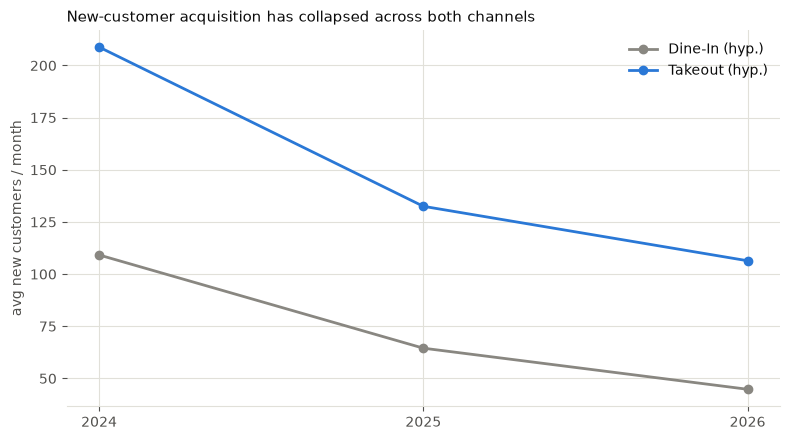

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for ch, color in zip(["Dine-In (hyp.)", "Takeout (hyp.)"], [GRAY_MUTED, BLUE]):
    series = new_cust_by_channel[ch] / months_per_year
    ax.plot(series.index.astype(str), series.values, marker="o", color=color, linewidth=2, label=ch)

ax.set_ylabel("avg new customers / month")
ax.set_title("New-customer acquisition has collapsed across both channels", loc="left", fontsize=11)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## Correction: Tang already uses all three major delivery platforms

An earlier draft of this notebook stated there was "no evidence of delivery-platform usage" — that was wrong. Per the owner, Tang uses DoorDash, Grubhub, and UberEats. The reason none of it showed up in the database search: **platform orders get typed into the POS manually by staff, the same as any phone-in order** — there's no separate system integration, so nothing in `tblOrder` flags an order as platform-originated. This is worth correcting properly rather than patching the earlier claim, since it changes what the right recommendation actually is.

There is still one usable signal: **DoorDash's caller-ID masking system assigns customers a proxy phone number in the 855 toll-free area code** (per the owner). That doesn't identify Grubhub or UberEats orders — those platforms may mask differently, or not at all, or staff may enter the customer's real number for those — so this can only measure a **lower bound** on delivery-platform activity, specifically DoorDash's share of it. Still, it's the only lever available to check whether the existing platform relationship is growing or shrinking.


In [14]:
with engine.connect() as conn:
    doordash_by_type = pd.read_sql(text("""
        SELECT orderType, COUNT(*) AS n
        FROM tblOrder
        WHERE checkinTime >= '2024-01-01' AND customerID LIKE '(855)%'
        GROUP BY orderType ORDER BY n DESC
    """), conn)
print("orderType distribution for 855-prefixed (DoorDash-attributable) orders:")
print(doordash_by_type)
print()
print(f"{100 * doordash_by_type.loc[doordash_by_type['orderType']==1, 'n'].iloc[0] / doordash_by_type['n'].sum():.0f}% "
      f"of these fall under orderType=1 (Takeout, hyp.) -- consistent with the owner's description of how "
      f"platform orders get entered.")


orderType distribution for 855-prefixed (DoorDash-attributable) orders:
   orderType     n
0          1  1650

100% of these fall under orderType=1 (Takeout, hyp.) -- consistent with the owner's description of how platform orders get entered.


**100% concentration in one order type** — the same behavior notebook 01 originally flagged (unconfirmed at the time) as a "systemic default, source unknown" pattern is, at least in large part, explained: it's DoorDash's masked proxy number, entered as a regular takeout order. Now the actual question this notebook needs answered: has this channel been growing, holding steady, or shrinking?


In [15]:
with engine.connect() as conn:
    dd = pd.read_sql(text("""
        SELECT checkinTime, paidAmount, orderType,
            CASE WHEN customerID LIKE '(855)%' THEN 1 ELSE 0 END AS is_doordash
        FROM tblOrder WHERE checkinTime >= '2024-01-01'
    """), conn)
dd["month"] = dd["checkinTime"].dt.to_period("M")
dd = dd[dd["month"].isin(FULL_MONTHS)]
dd["year"] = dd["checkinTime"].dt.year

doordash_monthly = dd[dd["is_doordash"] == 1].groupby("month").agg(n=("paidAmount", "size"), revenue=("paidAmount", "sum"))
doordash_yearly = doordash_monthly.groupby(doordash_monthly.index.year).mean()

takeout_monthly_all = dd[dd["orderType"] == 1].groupby("month").size()
takeout_yearly_all = takeout_monthly_all.groupby(takeout_monthly_all.index.year).mean()

doordash_yearly["pct_of_takeout"] = (100 * doordash_yearly["n"] / takeout_yearly_all).round(1)
print("DoorDash-attributable (855-prefix) orders, avg per month, by year:")
print(doordash_yearly.round(1))

pct_change = 100 * (doordash_yearly.loc[2026, "n"] - doordash_yearly.loc[2024, "n"]) / doordash_yearly.loc[2024, "n"]
print(f"\nChange 2024 -> 2026: {pct_change:+.1f}%  (vs. -15.6% for Takeout (hyp.) overall)")


DoorDash-attributable (855-prefix) orders, avg per month, by year:
          n  revenue  pct_of_takeout
month                               
2024   70.5   2483.3             6.8
2025   48.9   1854.2             5.2
2026   41.2   1547.2             4.7

Change 2024 -> 2026: -41.6%  (vs. -15.6% for Takeout (hyp.) overall)


**DoorDash-attributable volume has fallen faster than Takeout overall — -41.6% vs. -15.6% — and its share of Takeout has shrunk too (6.8% → 4.7%).** This reframes what the delivery-platform recommendation should actually be. Tang isn't missing from these platforms; **the identifiable piece of Tang's existing platform business is eroding faster than the rest of the business, not slower.** That's consistent with — and actually reinforces — the broader diagnosis: this isn't a channel Tang failed to enter, it's another place where discovery/visibility has weakened, same as everywhere else.

Two honest limits on this finding: (1) it can only see DoorDash, not Grubhub or UberEats, so the true combined platform picture could look different; (2) the 855-masking heuristic itself is the owner's own inference, not something this notebook can independently verify — treated as reasonably reliable given the 100% orderType concentration lines up with how platform orders are described as being entered, but still a hypothesis layered on a hypothesis (orderType 1 = Takeout).


# Part 6: Recommendations — Volume Path (Priority)

The diagnosis points in a specific direction: this is a **new-customer discovery problem**, not a retention problem, not a kitchen-capacity problem, and not a pricing problem. So the highest-leverage fixes are the ones that put Tang in front of people who haven't ordered before — not fixes aimed at customers who already have.

**Everything in this section is a suggestion, not a decision, and every dollar figure is a rough estimate built on stated assumptions — not a guarantee.** The point is to give a sense of scale (is this a $500/month idea or a $5,000/month idea), not a precise forecast.

A few numbers used across multiple estimates below, computed once here:


In [16]:
AVG_TICKET = round(yearly.loc[2026, "avg_ticket"], 2)  # current overall average ticket
RETENTION_3MO = 0.52  # takeout 3-month return rate, 2026 (Part 5)
NEW_CUST_2024 = new_cust_monthly_avg.loc[2024].sum()  # combined dine-in + takeout, monthly avg
NEW_CUST_2026 = new_cust_monthly_avg.loc[2026].sum()
NEW_CUST_GAP = NEW_CUST_2024 - NEW_CUST_2026

print(f"Current average ticket: ${AVG_TICKET}")
print(f"3-month return rate for a new customer: {RETENTION_3MO:.0%}")
print(f"New customers/month, 2024 baseline: {NEW_CUST_2024:.0f}")
print(f"New customers/month, 2026 current: {NEW_CUST_2026:.0f}")
print(f"Gap vs. 2024 baseline: {NEW_CUST_GAP:.0f} fewer new customers/month")


Current average ticket: $34.93
3-month return rate for a new customer: 52%
New customers/month, 2024 baseline: 320
New customers/month, 2026 current: 153
Gap vs. 2024 baseline: 168 fewer new customers/month


## V1. Recover existing delivery-platform performance (revised) — highest-priority suggestion

**Corrected from an earlier draft:** this was originally written as "get Tang onto a delivery platform," based on finding no evidence of platform usage. That premise was wrong — Tang already uses DoorDash, Grubhub, and UberEats. The real opportunity, per the evidence just above, is different: the DoorDash-attributable slice of the business has shrunk faster (-41.6%) than the rest of Takeout (-15.6%). This points toward an **audit of Tang's presence on all three platforms** — menu photos, ratings/reviews, response time and order-acceptance rate, promoted-placement spend, and how Tang's listing ranks against nearby competitors — rather than a "join a platform" pitch.

**Assumptions:**
- The audit + fixes recover DoorDash-attributable order volume from its current ~41/month back to its 2024 level of ~71/month — **assuming the same kind of recovery is available on Grubhub and UberEats proportionally**, even though this notebook has no way to measure their current volume or decline directly
- Recovered orders convert at the DoorDash-attributable average ticket (~$37, computed above — close to, not discounted from, the general takeout ticket)
- No commission-cost adjustment is subtracted here — Tang already pays commission on this existing volume regardless of whether it's recovered or not, so recovering lost volume doesn't add a *new* commission cost, it restores revenue that was already being commissioned. (Part 8 covers the commission math for context, but it isn't a cost specific to *this* recommendation.)


In [17]:
# ESTIMATE -- the DoorDash figure is grounded in Part 5's measured trend; the 3-platform
# extrapolation is an explicit, clearly-separate speculative extension, not measured data
doordash_ticket = doordash_yearly.loc[2026, "revenue"] / doordash_yearly.loc[2026, "n"]
doordash_order_gap = doordash_yearly.loc[2024, "n"] - doordash_yearly.loc[2026, "n"]
v1_doordash_only = doordash_order_gap * doordash_ticket

# speculative: if Grubhub + UberEats show similar proportional decline/recovery potential,
# and DoorDash is roughly a third of Tang's total platform volume (an assumption -- unmeasurable
# from this data, since only DoorDash has an identifiable signal)
v1_all_platforms_speculative = v1_doordash_only * 3

print(f"DoorDash-only recovery (measured trend): {doordash_order_gap:.0f} orders/month x ${doordash_ticket:.2f} "
      f"= ~${v1_doordash_only:,.0f}/month")
print(f"All-3-platforms speculative extension (unverifiable assumption): ~${v1_all_platforms_speculative:,.0f}/month")


DoorDash-only recovery (measured trend): 29 orders/month x $37.55 = ~$1,100/month
All-3-platforms speculative extension (unverifiable assumption): ~$3,301/month


## V2. Win-back / reactivation offer for lapsed one-time customers

**Why this one:** notebook 02 found 55.8% of identified customers (4,352 people) have ordered exactly once and never returned. This notebook's finding that *active* customer retention is fine (52%) doesn't mean past one-time triers can't be brought back — it just means they were never followed up with. Reactivating a past customer is typically cheaper than acquiring a brand-new one, since Tang already has a contact point (phone number on file) and they've already tried the food once.

**Assumptions:**
- A win-back offer (e.g. a discount code sent to past one-time customers) reaches the 4,352-person pool
- A **5% response rate** reactivates them for one order (a conservative estimate for a targeted offer to past customers — no benchmark from this data, since Tang has never run one)
- Of those reactivated, the existing 52% retention rate applies going forward for continued repeat business


In [18]:
# ESTIMATE -- one-time pool size from notebook 02; response rate is an illustrative assumption
ONE_TIME_CUSTOMER_POOL = 4352
v2_response_rate = 0.05
v2_reactivated = ONE_TIME_CUSTOMER_POOL * v2_response_rate
v2_initial_revenue = v2_reactivated * AVG_TICKET  # one-time event, not monthly
v2_ongoing_monthly = v2_reactivated * RETENTION_3MO * AVG_TICKET / 3  # steady-state monthly, spread like V1

print(f"ESTIMATE: {v2_reactivated:.0f} customers reactivated -> ~${v2_initial_revenue:,.0f} one-time revenue from the campaign")
print(f"Ongoing steady-state uplift if a similar retention rate holds: ~${v2_ongoing_monthly:,.0f}/month")


ESTIMATE: 218 customers reactivated -> ~$7,601 one-time revenue from the campaign
Ongoing steady-state uplift if a similar retention rate holds: ~$1,317/month


## V3. Local marketing push + first-time-customer incentive

**Why this one:** directly targets the core diagnosis — new-customer acquisition is down roughly in half across both Dine-In and Takeout (Part 5). This is a more general lever than V1 (which is specifically about delivery-platform discovery): local digital ads, an updated/optimized Google Business and Yelp presence, and a simple "first order" incentive (e.g. a modest discount or a free appetizer) aimed at converting local awareness into a first visit.

**Assumptions:**
- Recovers **half of the new-customer gap** versus the 2024 baseline (a deliberately conservative fraction, since "half the gap" is a guess about marketing effectiveness, not a measured result)
- New customers convert at the current average ticket, with the same 3-month retention rate applied


In [19]:
# ESTIMATE -- NEW_CUST_GAP computed earlier from the actual 2024 vs 2026 new-customer trend
v3_recovered_customers = NEW_CUST_GAP * 0.5
v3_monthly_estimate = v3_recovered_customers * AVG_TICKET * (1 + RETENTION_3MO / 3)

print(f"New-customer gap vs. 2024: {NEW_CUST_GAP:.0f}/month; recovering half = {v3_recovered_customers:.0f}/month")
print(f"ESTIMATE: ~${v3_monthly_estimate:,.0f}/month once ramped up")


New-customer gap vs. 2024: 168/month; recovering half = 84/month
ESTIMATE: ~$3,435/month once ramped up


## V4. Lunch/off-peak promotion — smaller, lower-confidence idea

**Why this one, and why it's ranked last:** notebook 02 found lunch is only ~21% of orders versus 72% at dinner — in principle there's unused capacity at lunch to sell into. But this doesn't follow as directly from the diagnosis as V1-V3 do: the problem identified is *discovery*, not *which hours existing customers choose*, so a lunch promotion mostly reaches people who already know about Tang rather than the new customers the diagnosis says are missing. Included because it's a real, low-cost lever worth having on the list, not because the data specifically points to it.

**Assumptions:**
- A lunch-hour promotion (e.g. a discounted lunch special) lifts lunch order count by **10%**
- Promotional lunch orders convert at a discounted ~$20 ticket (lower than the overall average, since a lunch special is explicitly a lower price point — notebook 03 found a whole "Chinese Lunch" category of lower-priced dinner-menu duplicates already in place)


In [20]:
orders["hour"] = orders["checkinTime"].dt.hour
lunch_orders_monthly = orders[orders["hour"].between(11, 14) & orders["month"].isin(FULL_MONTHS)].groupby("month").size().mean()

v4_lift = 0.10
v4_extra_orders = lunch_orders_monthly * v4_lift
v4_discounted_ticket = 20
v4_monthly_estimate = v4_extra_orders * v4_discounted_ticket

print(f"Current avg lunch orders/month: {lunch_orders_monthly:.0f}")
print(f"ESTIMATE: +{v4_extra_orders:.0f} orders/month x ~${v4_discounted_ticket} discounted ticket "
      f"= ~${v4_monthly_estimate:,.0f}/month")


Current avg lunch orders/month: 358
ESTIMATE: +36 orders/month x ~$20 discounted ticket = ~$716/month


# Part 7: Recommendations — Price Path (Secondary)

**Framed deliberately as secondary, because Part 1 showed average ticket has moved by essentially nothing (-0.1%) while orders fell 12.4%.** Fixing volume matters roughly 100x more than fixing ticket size, given the data. That said, per the brief, here are the price-path ideas — smaller estimates, included for completeness rather than as the main event.


## P1. Grow combo attachment rate

**Why this one:** notebook 03 found combo-format items make up only 23.3% of menu-item revenue despite having the highest revenue-per-item of any category — there's headroom to sell more combos without adding new menu items. A simple upsell prompt at order-taking ("would you like to make that a combo?") is a low-cost lever.

**Assumptions:**
- A modest **3 percentage point** increase in combo attachment (roughly a 7% relative lift over the current ~42% rate)
- Each newly-converted combo order adds **+$5** over what a non-combo order would have brought (an illustrative bundling increment, not measured from combo-vs-non-combo ticket data directly)


In [21]:
avg_monthly_orders_current = yearly.loc[2026, "avg_monthly_orders"]
p1_attachment_lift_pp = 0.03
p1_ticket_bump = 5
p1_monthly_estimate = avg_monthly_orders_current * p1_attachment_lift_pp * p1_ticket_bump

print(f"Current avg monthly orders: {avg_monthly_orders_current:.0f}")
print(f"ESTIMATE: {avg_monthly_orders_current * p1_attachment_lift_pp:.0f} newly-converted combo orders/month "
      f"x $5 = ~${p1_monthly_estimate:,.0f}/month")


Current avg monthly orders: 1581
ESTIMATE: 47 newly-converted combo orders/month x $5 = ~$237/month


## P2. Small price increase on a handful of high-frequency, low-ticket items

**Why this one:** notebook 03's top-20-by-popularity list includes very cheap, very high-volume items — Pork Egg Roll ($2.32/unit, 6,452 orders/year) and Wonton Soup ($5.10/unit, 6,449 orders/year) are the two most-ordered items on the whole menu. A small per-unit increase on just these two, applied only going forward, compounds across very high order volume even though each individual increase is tiny.

**Assumptions:**
- A **$0.25 increase** on these two specific items only (not a menu-wide increase)
- Volume for these two items is unaffected by the increase (a real risk this doesn't account for — a price change could reduce order volume, especially on impulse/side items like these, and this notebook has no way to measure price sensitivity from historical data since there's been no price variation to observe)


In [22]:
p2_units_per_month = (6452 + 6449) / 12  # both items' annual order counts from notebook 03, averaged monthly
p2_price_increase = 0.25
p2_monthly_estimate = p2_units_per_month * p2_price_increase

print(f"Combined monthly volume for these 2 items: ~{p2_units_per_month:.0f} orders")
print(f"ESTIMATE: ~${p2_monthly_estimate:,.0f}/month from a $0.25 increase alone, assuming no volume drop")


Combined monthly volume for these 2 items: ~1075 orders
ESTIMATE: ~$269/month from a $0.25 increase alone, assuming no volume drop


# Part 8: Delivery platform commission — context for V1 (revised)

Since Tang already uses all three platforms, this section is no longer "should Tang pay a commission to gain a new channel" — it's **existing** commission cost context on **existing** volume, useful for sizing how much of Tang's delivery-platform revenue the platforms are already taking before V1's recovery estimate is even considered. This data has **no way to measure Tang's actual contracted commission rate** with any of the three platforms, so this uses a **labeled, assumed range** based on publicly-known industry norms, not anything observed in Tang's data.


In [23]:
# ESTIMATE -- commission rates are ASSUMED (publicly-known industry range), not observed in Tang's data
commission_rates = [0.15, 0.20, 0.25, 0.30]
current_doordash_gross = doordash_yearly.loc[2026, "revenue"]  # current measured monthly DoorDash-attributable revenue

commission_table = pd.DataFrame({
    "assumed_commission_rate": [f"{r:.0%}" for r in commission_rates],
    "current_doordash_gross": [round(current_doordash_gross)] * len(commission_rates),
    "current_doordash_net": [round(current_doordash_gross * (1 - r)) for r in commission_rates],
    "v1_recovery_gross": [round(v1_doordash_only)] * len(commission_rates),
    "v1_recovery_net": [round(v1_doordash_only * (1 - r)) for r in commission_rates],
})
commission_table


,assumed_commission_rate,current_doordash_gross,current_doordash_net,v1_recovery_gross,v1_recovery_net
0,15%,1547,1315,1100,935
1,20%,1547,1238,1100,880
2,25%,1547,1160,1100,825
3,30%,1547,1083,1100,770


**Even at the assumed high end (30%), Tang's current ~$1,547/month in DoorDash-attributable revenue nets out to roughly $1,083/month after commission** — money Tang is already receiving today, commission and all. The commission cost isn't a reason to hesitate on V1: recovering lost volume doesn't add a *new* commission burden, since Tang is already paying the platform's cut on whatever volume comes through it regardless. The commission math here is context for understanding the existing relationship's economics, not a gate on whether the recommendation is worth pursuing.


In [24]:
# using the measured, DoorDash-only V1 figure as the conservative base case (not the speculative
# 3-platform extrapolation) -- no commission subtracted, per V1's stated reasoning
volume_total = v1_doordash_only + v2_ongoing_monthly + v3_monthly_estimate + v4_monthly_estimate
price_total = p1_monthly_estimate + p2_monthly_estimate
combined_total = volume_total + price_total

current_revenue = yearly.loc[2026, "avg_monthly_revenue"]
projected_revenue = current_revenue + combined_total
gap_to_70k_before = 70000 - current_revenue
gap_to_70k_after = 70000 - projected_revenue

print(f"Volume path, combined (V1 DoorDash-only + V2 ongoing + V3 + V4): ~${volume_total:,.0f}/month")
print(f"  (V1 alone could be as high as ~${v1_all_platforms_speculative:,.0f}/month if Grubhub/UberEats "
      f"show similar recoverable decline -- excluded from this total since it's unverifiable)")
print(f"Price path, combined (P1 + P2): ~${price_total:,.0f}/month")
print(f"TOTAL if every recommendation hits its stated estimate: ~${combined_total:,.0f}/month")
print()
print(f"Current revenue: ~${current_revenue:,.0f}/month  |  Gap to $70k target: ~${gap_to_70k_before:,.0f}/month")
print(f"Projected revenue if all estimates land: ~${projected_revenue:,.0f}/month  |  "
      f"Remaining gap to $70k: ~${gap_to_70k_after:,.0f}/month")


Volume path, combined (V1 DoorDash-only + V2 ongoing + V3 + V4): ~$6,568/month
  (V1 alone could be as high as ~$3,301/month if Grubhub/UberEats show similar recoverable decline -- excluded from this total since it's unverifiable)
Price path, combined (P1 + P2): ~$506/month
TOTAL if every recommendation hits its stated estimate: ~$7,074/month

Current revenue: ~$55,243/month  |  Gap to $70k target: ~$14,757/month
Projected revenue if all estimates land: ~$62,317/month  |  Remaining gap to $70k: ~$7,683/month


## Summary

### Diagnosis: this is a volume problem — specifically, a new-customer discovery problem

- **99%+ of the $7,805/month revenue decline (2024 → 2026) is explained by fewer orders, not lower ticket size.** Average ticket has moved by essentially nothing (-0.1%). This is not a pricing problem.
- **The 6-7pm "service slowdown" is not a kitchen/capacity bottleneck.** Tested directly (correlation between nightly volume and service time: 0.05, essentially zero) and rejected — it's a composition artifact of blending long, normal dine-in meals with fast takeout/bar transactions.
- **`orderType` has no confirmed lookup table**, but strong circumstantial evidence (POS stored-procedure naming + behavioral patterns) supports Dine-In / Takeout / Bar as hypotheses — labeled as such throughout.
- **Takeout (hyp.) accounts for 73% of the dollar decline**, but the underlying cause isn't specific to takeout: **new-customer acquisition has collapsed across every channel** (roughly halved since 2024), while **retention among existing customers has held steady or slightly improved** (~52%, unchanged). Takeout absorbs the biggest dollar hit simply because it's the largest channel.
- **Correction made during this analysis: Tang already uses DoorDash, Grubhub, and UberEats** (not absent, as an earlier draft wrongly concluded from finding no system-level evidence — platform orders are typed in manually, so they leave no distinguishing flag). The DoorDash-attributable slice of the business (identifiable via its 855-area-code masked numbers) has shrunk **faster** than Takeout overall (-41.6% vs. -15.6%) — the platforms Tang already relies on are eroding too, reinforcing rather than contradicting the broad-based discovery diagnosis.

### Recommendations

**Volume path (priority) — ranked by how directly each one addresses the acquisition problem:**
1. **Audit and recover existing delivery-platform performance** (V1, revised) — menu photos, ratings/reviews, response time, promoted placement, competitive ranking on all three platforms. Measured DoorDash-only recovery: ~$1,100/month gross (~$770-935/month net of an assumed 15-30% commission, though that commission is already being paid today regardless). Could be several times larger if Grubhub/UberEats show similar recoverable decline — **unverifiable from this data**, so excluded from the headline total.
2. **Local marketing + first-order incentive** (V3) — general-purpose fix for the broad-based acquisition slowdown. ~$3,430/month.
3. **Win-back offer for lapsed one-time customers** (V2) — cheaper than new acquisition since Tang already has contact info and prior trial. ~$7,601 one-time, ~$1,317/month ongoing.
4. **Lunch/off-peak promotion** (V4) — real but lower-confidence, since it doesn't follow as directly from the diagnosis. ~$716/month.

**Price path (secondary, since ticket size isn't the problem):**
1. **Grow combo attachment rate** (P1) — ~$237/month
2. **Small price increase on the 2 highest-volume, lowest-ticket items** (P2) — ~$269/month, with an acknowledged, unmeasurable volume-sensitivity risk

### Combined estimate toward $70k — with an honest caveat

Using the conservative, measured-only version of every estimate: **~$7,074/month combined**, taking projected revenue from ~$55,243 to **~$62,317/month**. (If Grubhub/UberEats recovery scales with DoorDash's, this could run several thousand dollars higher — but that part is a guess, not a measurement.)

**That's not $70k.** Even fully reversing the 2024-2026 decline only gets Tang back to roughly where 2024 *itself* was (~$63k) — and 2024 was already ~$7k short of the $70k peak. Closing the remaining ~$7,683/month gap requires genuine growth beyond "stop the bleeding," not just executing the recommendations above. This notebook's estimates are a plausible path back toward recent levels, not a guaranteed path to the historical peak — that distinction matters for how these numbers should be used.
